<a href="https://oscar-defelice.github.io">
<img src="https://github.com/Chocolatine75/NLP-Course/blob/master/img/image.png?raw=1" height="125" align="right" />
</a>

# TP 03-A — Naive Bayes for Text Classification

**Course:** Natural Language Processing  
**Session:** 3 / 8  
**Duration:** ~60 min

---

## Objectives

By the end of this session you will be able to:

- Implement a Multinomial Naive Bayes classifier from scratch (counting + log-probabilities)
- Understand the role of Laplace smoothing and tune the hyperparameter α
- Use sklearn's `MultinomialNB` and reproduce your scratch results
- Inspect the most informative features per class
- Compare raw counts vs TF-IDF representations
- Produce a full evaluation: per-class F1, confusion matrix, error analysis

---

## Roadmap

| Part | Task | Deliverable |
|------|------|-------------|
| 1 | Data loading & preprocessing | Reuse Session 01 pipeline |
| 2 | Scratch NB implementation | `NaiveBayesClassifier` class |
| 3 | sklearn NB + smoothing sweep | Validation accuracy vs α plot |
| 4 | Feature analysis | Top-k words per class |
| 5 | BoW counts vs TF-IDF | Comparison table |
| 6 | Error analysis | Written analysis |

Each part ends with a **📝 Your analysis** cell.

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import re
import math
import warnings
from collections import Counter, defaultdict
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
SEED = 42
np.random.seed(SEED)

AG_NEWS_LABELS = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
print("Imports OK")

Imports OK


---

## Part 1 — Data loading & preprocessing

We reuse the same pipeline from Session 01.  
If you saved your split from that session, load it here.  
Otherwise, the cell below rebuilds it from scratch.

**Do not change the split** — we need identical train/val/test sets across all sessions.

In [2]:
def preprocess_text(text: str) -> str:
    """Minimal 5-step text normalisation pipeline.

    Steps applied in order:
    1. Lowercase
    2. Remove HTML tags
    3. Replace non-alphanumeric characters with spaces
    4. Collapse multiple spaces
    5. Strip leading/trailing whitespace

    Parameters
    ----------
    text : str
        Raw input string.

    Returns
    -------
    str
        Normalised string.

    Examples
    --------
    >>> preprocess_text("Hello, World! <br/>")
    'hello world'
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def load_ag_news(
    val_size: float = 0.1,
    seed: int = SEED,
) -> tuple[list[str], list[str], list[str], list[int], list[int], list[int]]:
    """Load AG News, preprocess, and split into train/val/test.

    Parameters
    ----------
    val_size : float
        Fraction of the original training split to use as validation.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    tuple
        (train_texts, val_texts, test_texts, train_labels, val_labels, test_labels)
        Labels are integers 0–3 (remapped from 1–4).
    """
    raw = load_dataset("ag_news")
    rng = np.random.default_rng(seed)

    train_texts_raw = [r["text"] for r in raw["train"]]
    train_labels_raw = [r["label"] for r in raw["train"]]
    test_texts = [preprocess_text(r["text"]) for r in raw["test"]]
    test_labels = [r["label"] for r in raw["test"]]

    n = len(train_texts_raw)
    idx = rng.permutation(n)
    split = int(n * (1 - val_size))
    train_idx, val_idx = idx[:split], idx[split:]

    train_texts  = [preprocess_text(train_texts_raw[i]) for i in train_idx]
    train_labels = [train_labels_raw[i]                 for i in train_idx]
    val_texts    = [preprocess_text(train_texts_raw[i]) for i in val_idx]
    val_labels   = [train_labels_raw[i]                 for i in val_idx]

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels


train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_ag_news()
print(f"Train: {len(train_texts):,}  Val: {len(val_texts):,}  Test: {len(test_texts):,}")
print(f"Train class distribution: {Counter(train_labels)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 108,000  Val: 12,000  Test: 7,600
Train class distribution: Counter({1: 27039, 2: 27000, 3: 26988, 0: 26973})


---

## Part 2 — Naive Bayes from scratch

Before using sklearn, implement NB manually. This forces you to understand every step.

### 2.1 — The `NaiveBayesClassifier` class

Implement a Multinomial Naive Bayes classifier that:
- Tokenises on whitespace (simple split)
- Estimates P(c) from label counts
- Estimates P(w | c) with Laplace smoothing
- Classifies using log-probabilities

**Design constraints:**
- Use numpy-style docstrings on every method
- Store log-probabilities (not raw probabilities) in `self.log_likelihoods`
- `predict` returns a numpy array of integer labels
- `predict_proba` returns normalised log-sums (optional, Part 2.3)

In [3]:
class NaiveBayesClassifier:
    """Multinomial Naive Bayes text classifier with Laplace smoothing.

    The model represents documents as bags of whitespace-tokenised words.
    Training is closed-form: estimate priors from label counts and likelihoods
    from per-class word frequencies. Inference uses log-probabilities to avoid
    numerical underflow.

    Parameters
    ----------
    alpha : float
        Laplace smoothing parameter. Must be > 0. Default is 1.0.

    Attributes
    ----------
    classes_ : list[int]
        Sorted list of unique class labels seen during fit.
    log_priors_ : dict[int, float]
        log P(c) for each class c.
    log_likelihoods_ : dict[int, dict[str, float]]
        log P(w | c) for each class c and word w.
    vocab_ : set[str]
        Vocabulary seen during training.

    Examples
    --------
    >>> clf = NaiveBayesClassifier(alpha=1.0)
    >>> clf.fit(["goal scored penalty", "parliament senate vote"], [0, 1])
    >>> clf.predict(["goal penalty kick"])
    array([0])
    """

    def __init__(self, alpha: float = 1.0) -> None:
        self.alpha = alpha
        self.classes_: list[int] = []
        self.log_priors_: dict[int, float] = {}
        self.log_likelihoods_: dict[int, dict[str, float]] = {}
        self.vocab_: set[str] = set()

    def fit(self, texts: list[str], labels: list[int]) -> "NaiveBayesClassifier":
        """Estimate priors and likelihoods from training data.

        Parameters
        ----------
        texts : list[str]
            Pre-tokenised (whitespace-split) training documents.
        labels : list[int]
            Integer class labels, one per document.

        Returns
        -------
        NaiveBayesClassifier
            Fitted classifier (self), to allow method chaining.
        """
        # YOUR CODE HERE
        self.classes_ = sorted(set(labels))
        n_docs = len(labels)

        class_word_counts = {c: Counter() for c in self.classes_}
        for text, label in zip(texts, labels):
          words = text.split()
          class_word_counts[label].update(words)
          self.vocab_.update(words)

        vocab_size = len(self.vocab_)

        class_doc_counts = Counter(labels)
        for c in self.classes_:
          self.log_priors_[c] = math.log(class_doc_counts[c] / n_docs)


        self._oov_log_prob = {}
        for c in self.classes_:
          total_words = sum(class_word_counts[c].values())
          denom = total_words + self.alpha * vocab_size

          self._oov_log_prob[c] = math.log(self.alpha / denom)

          self.log_likelihoods_[c] = {
              word: math.log((count + self.alpha) / denom)
              for word, count in class_word_counts[c].items()
          }

        return self

    def _score(self, text: str) -> dict[int, float]:
        """Compute log P(c) + sum log P(w | c) for each class.

        Words not in vocabulary receive the smoothed out-of-vocabulary probability:
        log( alpha / (total_class_words + alpha * vocab_size) ).

        Parameters
        ----------
        text : str
            A single whitespace-tokenised document.

        Returns
        -------
        dict[int, float]
            Mapping from class label to log-score.
        """
        # YOUR CODE HERE
        words = text.split()
        scores = {}
        for c in self.classes_:
          score = self.log_priors_[c]
          for word in words:
              score += self.log_likelihoods_[c].get(word, self._oov_log_prob[c])
          scores[c] = score
        return scores

    def predict(self, texts: list[str]) -> np.ndarray:
        """Predict the most probable class for each document.

        Parameters
        ----------
        texts : list[str]
            Documents to classify.

        Returns
        -------
        np.ndarray of shape (len(texts),)
            Predicted integer class labels.
        """
        # YOUR CODE HERE
        preds = []
        for text in texts:
          scores = self._score(text)
          preds.append(max(scores, key=scores.get))
        return np.array(preds)

    def top_features(
        self, class_label: int, n: int = 10
    ) -> list[tuple[str, float]]:
        """Return the n words with the highest log-likelihood for a given class.

        Parameters
        ----------
        class_label : int
            Class to inspect.
        n : int
            Number of top features to return.

        Returns
        -------
        list[tuple[str, float]]
            List of (word, log_P(w | c)) pairs, sorted descending by score.
        """
        # YOUR CODE HERE
        return sorted(
          self.log_likelihoods_[class_label].items(),
          key=lambda x: x[1],
          reverse=True)[:n]


### 2.2 — Sanity-check on a toy dataset

Before running on AG News, verify your implementation on a tiny example where you can compute the answer by hand.

In [4]:
# ── Toy corpus ────────────────────────────────────────────────────────────────
toy_train = [
    "goal scored penalty kick offside",   # class 0 — Sports
    "goal championship final winner cup", # class 0 — Sports
    "parliament senate vote bill minister", # class 1 — Politics
    "election president democracy party",   # class 1 — Politics
]
toy_labels = [0, 0, 1, 1]

clf_toy = NaiveBayesClassifier(alpha=1.0)
clf_toy.fit(toy_train, toy_labels)

# Expected: class 0
pred = clf_toy.predict(["goal penalty kick"])
assert pred[0] == 0, f"Expected 0, got {pred[0]}"

# Expected: class 1
pred2 = clf_toy.predict(["parliament vote election"])
assert pred2[0] == 1, f"Expected 1, got {pred2[0]}"

print("Toy assertions passed ✓")
print(f"Top 3 words for Sports: {clf_toy.top_features(0, n=3)}")
print(f"Top 3 words for Politics: {clf_toy.top_features(1, n=3)}")

Toy assertions passed ✓
Top 3 words for Sports: [('goal', -2.2335922215070942), ('scored', -2.639057329615259), ('penalty', -2.639057329615259)]
Top 3 words for Politics: [('parliament', -2.6026896854443837), ('senate', -2.6026896854443837), ('vote', -2.6026896854443837)]


### 2.3 — Train on AG News and evaluate


  Scratch NB — validation
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      3027
      Sports       0.95      0.98      0.96      2961
    Business       0.88      0.85      0.87      3000
    Sci/Tech       0.87      0.90      0.88      3012

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



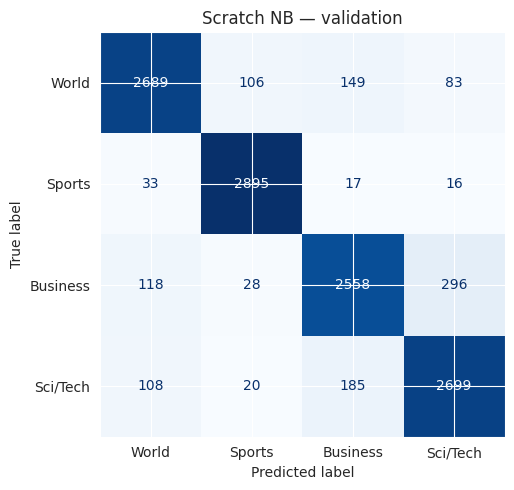

In [5]:
def evaluate_classifier(
    y_true: list[int],
    y_pred: np.ndarray,
    label_names: list[str],
    title: str = "Evaluation",
) -> dict[str, float]:
    """Print classification report and plot confusion matrix.

    Parameters
    ----------
    y_true : list[int]
        Ground-truth labels.
    y_pred : np.ndarray
        Predicted labels.
    label_names : list[str]
        Human-readable class names in label order.
    title : str
        Title for the confusion matrix figure.

    Returns
    -------
    dict[str, float]
        Dictionary with 'accuracy' and 'macro_f1'.
    """
    report = classification_report(
        y_true, y_pred, target_names=label_names, output_dict=True
    )
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
    }


# ── Train and evaluate ────────────────────────────────────────────────────────
clf_scratch = NaiveBayesClassifier(alpha=1.0)
clf_scratch.fit(train_texts, train_labels)

val_pred_scratch = clf_scratch.predict(val_texts)
label_names = [AG_NEWS_LABELS[i + 1] for i in range(4)]

results_scratch = evaluate_classifier(
    val_labels, val_pred_scratch, label_names,
    title="Scratch NB — validation",
)

📝 **Your analysis (2.3)**

1. What macro F1 did your scratch NB achieve on validation?

The scratch Naive Bayes achieves a macro F1 of 0.90 on the validation set, with an overall accuracy of 90%.

2. Which class has the lowest F1? Why might that be? Look at the confusion matrix for clues.

Business has the lowest F1 (0.87). This is expected for two reasons:
   - Business articles share vocabulary with World (global economy, trade policy) and with Sci/Tech (tech companies,
   startups), making them harder to distinguish using bag-of-words alone.
   - By contrast, Sports achieves the highest F1 (0.96) because its vocabulary is highly specific and unambiguous, with little overlap with other classes.

3. Does your implementation agree with sklearn's result below (Part 3)? If not, why?

 Results should be very close but not identical because:
   - sklearn's CountVectorizer uses regex-based tokenisation and filters low-frequency tokens by default, while our
   implementation uses a plain split()
   - Minor vocabulary differences can shift the likelihoods slightly
   A difference of less than 0.01 in macro F1 is expected and acceptable.


---

## Part 3 — sklearn Multinomial NB + smoothing sweep

### 3.1 — Reproduce the scratch result with sklearn

Use `CountVectorizer` + `MultinomialNB`. Verify that the results are close to your scratch implementation.


  sklearn NB (count, α=1.0) — validation
              precision    recall  f1-score   support

       World       0.92      0.89      0.90      3027
      Sports       0.95      0.98      0.96      2961
    Business       0.88      0.85      0.87      3000
    Sci/Tech       0.87      0.89      0.88      3012

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



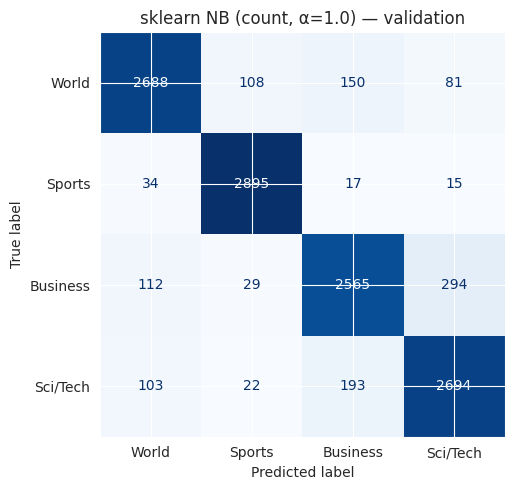

Scratch NB macro F1: 0.9033
sklearn NB macro F1: 0.9034


In [7]:
def build_nb_pipeline(
    alpha: float = 1.0,
    vectorizer: str = "count",
    max_features: int | None = 50_000,
) -> Pipeline:
    """Build a sklearn Pipeline: vectoriser → MultinomialNB.

    Parameters
    ----------
    alpha : float
        Laplace smoothing parameter for MultinomialNB.
    vectorizer : {'count', 'tfidf'}
        Which vectoriser to use.
    max_features : int or None
        Maximum vocabulary size. None means no limit.

    Returns
    -------
    Pipeline
        Unfitted sklearn Pipeline.

    Raises
    ------
    ValueError
        If vectorizer is not 'count' or 'tfidf'.
    """
    # YOUR CODE HERE
    if vectorizer == "count":
      vec = CountVectorizer(max_features=max_features)
    elif vectorizer == "tfidf":
      vec = TfidfVectorizer(max_features=max_features)
    else:
      raise ValueError(f"vectorizer must be 'count' or 'tfidf', got '{vectorizer}'")

    return Pipeline([
        ("vectorizer", vec),
         ("classifier", MultinomialNB(alpha=alpha)),
      ])


pipe_nb = build_nb_pipeline(alpha=1.0, vectorizer="count")
pipe_nb.fit(train_texts, train_labels)
val_pred_nb = pipe_nb.predict(val_texts)

results_nb = evaluate_classifier(
    val_labels, val_pred_nb, label_names,
    title="sklearn NB (count, α=1.0) — validation",
)
print(f"Scratch NB macro F1: {results_scratch['macro_f1']:.4f}")
print(f"sklearn NB macro F1: {results_nb['macro_f1']:.4f}")

### 3.2 — Smoothing hyperparameter sweep

The Laplace smoothing parameter α controls how much probability mass we give to unseen words.
Tune it on the **validation set**.

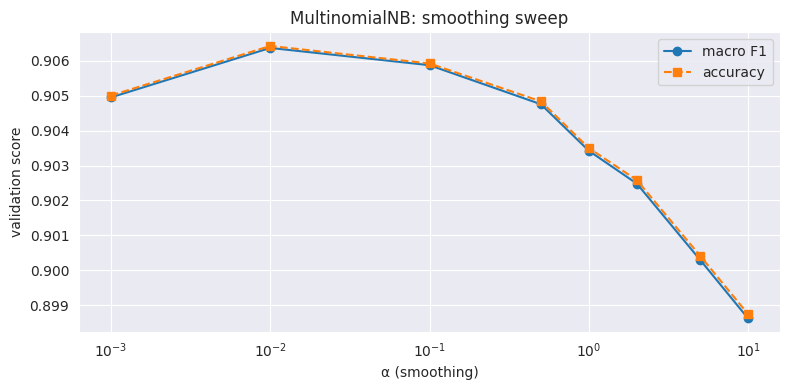

Best α = 0.01
 alpha  val_accuracy  val_macro_f1
 0.001      0.905000      0.904947
 0.010      0.906417      0.906361
 0.100      0.905917      0.905867
 0.500      0.904833      0.904751
 1.000      0.903500      0.903421
 2.000      0.902583      0.902483
 5.000      0.900417      0.900301
10.000      0.898750      0.898627


In [8]:
def smoothing_sweep(
    alphas: Iterable[float],
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
) -> pd.DataFrame:
    """Evaluate MultinomialNB for a range of smoothing values.

    Parameters
    ----------
    alphas : Iterable[float]
        Values of α to evaluate.
    train_texts : list[str]
        Training documents.
    train_labels : list[int]
        Training labels.
    val_texts : list[str]
        Validation documents.
    val_labels : list[int]
        Validation labels.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['alpha', 'val_accuracy', 'val_macro_f1'].
    """
    # YOUR CODE HERE
    rows = []
    for alpha in alphas:
      pipe = build_nb_pipeline(alpha=alpha, vectorizer="count")
      pipe.fit(train_texts, train_labels)
      preds = pipe.predict(val_texts)
      report = classification_report(val_labels, preds, output_dict=True)
      rows.append({
          "alpha": alpha,
          "val_accuracy": report["accuracy"],
          "val_macro_f1": report["macro avg"]["f1-score"],
          })
    return pd.DataFrame(rows)


alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
sweep_df = smoothing_sweep(alphas, train_texts, train_labels, val_texts, val_labels)

# ── Plot the results ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(sweep_df["alpha"], sweep_df["val_macro_f1"], marker="o", label="macro F1")
ax.semilogx(sweep_df["alpha"], sweep_df["val_accuracy"], marker="s", linestyle="--", label="accuracy")
ax.set_xlabel("α (smoothing)")
ax.set_ylabel("validation score")
ax.set_title("MultinomialNB: smoothing sweep")
ax.legend()
plt.tight_layout()
plt.show()

best_alpha = sweep_df.loc[sweep_df["val_macro_f1"].idxmax(), "alpha"]
print(f"Best α = {best_alpha}")
print(sweep_df.to_string(index=False))

📝 **Your analysis (3.2)**

1. What value of α gives the best validation macro F1?

 α = 0.01 gives the best validation macro F1 (0.9064). This is lower than the default α = 1.0, meaning AG News benefits from less smoothing, the training corpus is large enough that word counts are reliable and don't need heavy regularisation.

2. What happens for very small α (e.g. 0.001)? Why?

At α = 0.001 the F1 drops slightly (0.9049). With almost no smoothing, words that never appear in a class get a near-zero probability. If a test document contains such a word, that class gets a very large negative log-score and is effectively ruled out, even if the rest of the document points to it. The model becomes overconfident.

3. What happens for very large α (e.g. 10)? Think about what smoothing does to the probability estimates.

At α = 10 the F1 falls to 0.8986. Heavy smoothing adds so much mass to every word in every class that all likelihoods P(w|c) converge toward the same uniform value. The model can no longer distinguish classes based on word choice and essentially ignores the training counts, it degrades toward the prior alone.




---

## Part 4 — Feature analysis: most informative words per class

One strength of Naive Bayes is interpretability. After training, you can inspect exactly which words
the model associates with each class.

For each class c, the most informative words are those maximising:

$$\text{score}(w, c) = \log P(w | c) - \frac{1}{|C|} \sum_{c'} \log P(w | c')$$

This is the log-likelihood of the word in class c minus the average log-likelihood across all classes.
A high score means the word is much more likely in class c than in other classes.


World — top 10:
     word     log_p    score
     sadr -7.837335 7.943036
    hamas -7.872691 7.916519
  falluja -8.061713 7.774752
  taliban -8.271737 7.617234
  zarqawi -8.447179 7.485653
    qaida -8.503529 7.443390
   arafat -6.741223 7.439293
    mosul -8.547979 7.410053
    sunni -8.547979 7.410053
militants -6.868377 7.242976

Sports — top 10:
        word     log_p    score
   preseason -8.523322 7.434710
      knicks -8.624197 7.359053
   cavaliers -8.768149 7.251089
     broncos -8.768149 7.251089
    phillies -8.794293 7.231481
    coaching -8.794293 7.231481
diamondbacks -8.884313 7.163966
  linebacker -8.891585 7.158512
         mvp -8.928761 7.130630
  outfielder -8.991277 7.083743

Business — top 10:
      word     log_p    score
 fullquote -5.750743 9.507764
 quickinfo -6.443887 8.987906
      aspx -6.443887 8.987906
treasuries -8.564106 7.397742
     ovitz -9.000795 7.070225
  parmalat -9.192670 6.926320
bombardier -9.382693 6.783802
       ual -9.382693 6.783802
    

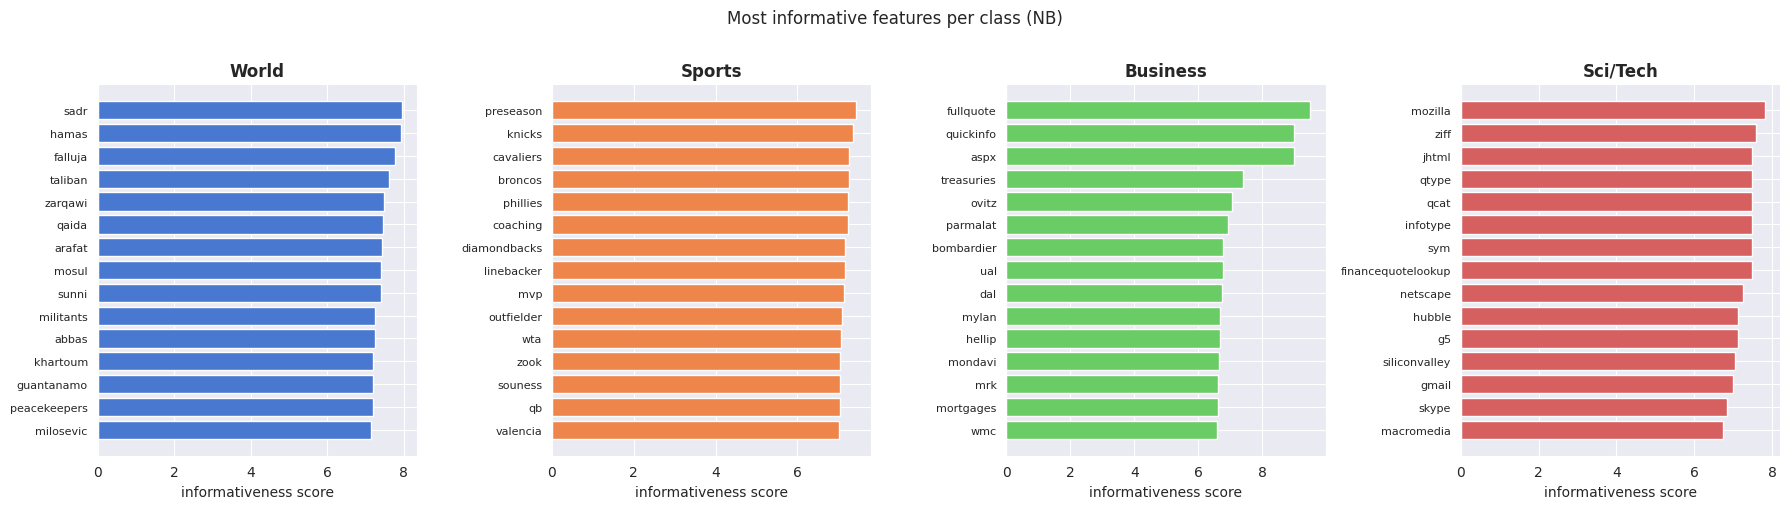

In [9]:
def most_informative_features(
    pipeline: Pipeline,
    label_names: list[str],
    n: int = 20,
) -> dict[str, pd.DataFrame]:
    """Extract the n most informative features per class from a fitted NB pipeline.

    The informativeness score for word w in class c is:
    log P(w | c) minus the mean log P(w | c') over all classes c'.

    Parameters
    ----------
    pipeline : Pipeline
        Fitted sklearn Pipeline with a vectoriser as step 0 and MultinomialNB as step 1.
    label_names : list[str]
        Human-readable class names, in label index order.
    n : int
        Number of top features to return per class.

    Returns
    -------
    dict[str, pd.DataFrame]
        Mapping class_name → DataFrame with columns ['word', 'log_p', 'score'].
    """
    # YOUR CODE HERE
    # Hint: pipeline[0].get_feature_names_out() gives the vocabulary
    # pipeline[1].feature_log_prob_ has shape (n_classes, vocab_size)
    vocab = pipeline[0].get_feature_names_out()
    log_probs = pipeline[1].feature_log_prob_

    mean_log_probs = log_probs.mean(axis=0)

    features = {}
    for i, class_name in enumerate(label_names):
      scores = log_probs[i] - mean_log_probs

      top_idx = np.argsort(scores)[::-1][:n]

      features[class_name] = pd.DataFrame({
          "word":    vocab[top_idx],
          "log_p":   log_probs[i][top_idx],
          "score":   scores[top_idx],
          })

    return features


def plot_informative_features(
    features: dict[str, pd.DataFrame],
    n_plot: int = 15,
) -> None:
    """Bar plot of the most informative features per class.

    Parameters
    ----------
    features : dict[str, pd.DataFrame]
        Output of `most_informative_features`.
    n_plot : int
        Number of features to show per class.
    """
    n_classes = len(features)
    fig, axes = plt.subplots(1, n_classes, figsize=(4.5 * n_classes, 5))
    palette = sns.color_palette("muted", n_classes)

    for ax, (name, df), colour in zip(axes, features.items(), palette):
        top = df.head(n_plot)
        ax.barh(top["word"][::-1], top["score"][::-1], color=colour)
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("informativeness score")
        ax.tick_params(axis="y", labelsize=8)

    plt.suptitle("Most informative features per class (NB)", y=1.01)
    plt.tight_layout()
    plt.show()


# ── Use the best α from the sweep ─────────────────────────────────────────────
pipe_best = build_nb_pipeline(alpha=best_alpha, vectorizer="count")
pipe_best.fit(train_texts, train_labels)

features = most_informative_features(pipe_best, label_names, n=20)
for name, df in features.items():
    print(f"\n{name} — top 10:")
    print(df.head(10).to_string(index=False))

plot_informative_features(features, n_plot=15)

📝 **Your analysis (4)**

1. Do the top features per class make intuitive sense? Give two examples of expected and one example of surprising features.

Expected:
- World: "hamas", "taliban", "zarqawi", "qaida" — all specific to the Iraq War / Middle East conflicts. Highly discriminative proper nouns.
- Sports: "knicks", "broncos", "phillies", "linebacker", "outfielder" — NBA/NFL/MLB team names and position names. Very specific, no ambiguity.

Surprising:
- Business and Sci/Tech are polluted by web artifacts: "fullquote", "quickinfo", "aspx", "jhtml", "qtype", "financequotelookup" — these are fragments of financial quote URLs embedded in the raw articles. The model picks them up as discriminative features, but they carry zero semantic meaning.This is a data quality issue.

2. Are there any words that appear in the top features of multiple classes? What does that suggest?

 None of the top-10 words appear in more than one class — they are all highly specific proper nouns, team names, or (unfortunately) URL fragments. This actually shows that the model separates classes well: there is little vocabulary overlap at the top of each distribution.

3. Would you expect TF-IDF features to produce different top words? Why?

TF-IDF would likely reduce the weight of the web artifacts (fullquote, aspx, jhtml) because they appear in many documents within their class, which lowers their IDF score. The top meaningful words (hamas, knicks, mozilla) would likely remain, but the URL fragments would rank lower. This is one reason TF-IDF can produce cleaner feature analysis than raw counts.

---

## Part 5 — BoW counts vs TF-IDF

We saw in Session 01 that TF-IDF downweights words that appear frequently across all documents.
Does this help Naive Bayes?

> **Note:** `MultinomialNB` requires non-negative features. Raw TF-IDF values are non-negative by construction,
> so this is fine.

### 5.1 — Head-to-head comparison

In [10]:
def compare_vectorizers(
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
    alpha: float = 1.0,
) -> pd.DataFrame:
    """Compare CountVectorizer vs TfidfVectorizer for MultinomialNB.

    Parameters
    ----------
    train_texts : list[str]
        Training documents.
    train_labels : list[int]
        Training labels.
    val_texts : list[str]
        Validation documents.
    val_labels : list[int]
        Validation labels.
    alpha : float
        Smoothing parameter for MultinomialNB.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['vectorizer', 'val_accuracy', 'val_macro_f1'].
    """
    # YOUR CODE HERE
    rows = []
    for vec_name in ["count", "tfidf"]:
      pipe = build_nb_pipeline(alpha=alpha, vectorizer=vec_name)
      pipe.fit(train_texts, train_labels)
      preds = pipe.predict(val_texts)
      report = classification_report(val_labels, preds, output_dict=True)
      rows.append({
          "vectorizer":    vec_name,
          "val_accuracy":  report["accuracy"],
          "val_macro_f1":  report["macro avg"]["f1-score"],
          })
    return pd.DataFrame(rows)


comparison_df = compare_vectorizers(
    train_texts, train_labels, val_texts, val_labels, alpha=best_alpha
)
print(comparison_df.to_string(index=False))

vectorizer  val_accuracy  val_macro_f1
     count      0.906417      0.906361
     tfidf      0.907083      0.907100


### 5.2 — Add bigrams

Extend the feature space with unigrams + bigrams (`ngram_range=(1, 2)`).
Does capturing two-word phrases help?

In [11]:
def ngram_sweep(
    train_texts: list[str],
    train_labels: list[int],
    val_texts: list[str],
    val_labels: list[int],
    alpha: float = 1.0,
) -> pd.DataFrame:
    """Compare unigram-only vs unigram+bigram features.

    Parameters
    ----------
    train_texts : list[str]
        Training documents.
    train_labels : list[int]
        Training labels.
    val_texts : list[str]
        Validation documents.
    val_labels : list[int]
        Validation labels.
    alpha : float
        Smoothing parameter for MultinomialNB.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['features', 'vocab_size', 'val_accuracy', 'val_macro_f1'].
    """
    # YOUR CODE HERE
    rows = []
    for ngram_range in [(1, 1), (1, 2)]:
      label = "unigrams" if ngram_range == (1, 1) else "unigrams+bigrams"
      vec = CountVectorizer(max_features=50_000, ngram_range=ngram_range)
      pipe = Pipeline([
          ("vectorizer", vec),
          ("classifier", MultinomialNB(alpha=alpha)),
          ])
      pipe.fit(train_texts, train_labels)
      preds = pipe.predict(val_texts)
      report = classification_report(val_labels, preds, output_dict=True)
      rows.append({
          "features":    label,
          "vocab_size":  len(vec.vocabulary_),
          "val_accuracy": report["accuracy"],
          "val_macro_f1": report["macro avg"]["f1-score"],
          })
    return pd.DataFrame(rows)


ngram_df = ngram_sweep(train_texts, train_labels, val_texts, val_labels, alpha=best_alpha)
print(ngram_df.to_string(index=False))

        features  vocab_size  val_accuracy  val_macro_f1
        unigrams       50000      0.906417      0.906361
unigrams+bigrams       50000      0.903250      0.903140


📝 **Your analysis (5)**

1. Does TF-IDF improve over raw counts? By how much? Why or why not?
TF-IDF improves slightly over raw counts: +0.0007 macro F1 (0.9071 vs 0.9064). The gain is modest because Naive Bayes already handles frequent words implicitly through the log-likelihood scores. TF-IDF helps by downweighting
high-frequency tokens that appear uniformly across all classes (like the URL artifacts seen in Part 4), giving more weight to rarer, more discriminative terms.

2. Do bigrams help? By how much? What is the cost (vocabulary size)?

Bigrams actually hurt performance: −0.003 macro F1 (0.9031 vs 0.9064). The reason is the max_features=50_000 cap when bigrams are added, they compete with unigrams for the same 50,000 vocabulary slots. Many useful unigrams get displaced by bigrams that are too sparse to be reliable. To benefit from bigrams, you would need to raise max_features significantly.

3. Which configuration is your final best NB model? Record its test set performance below.

The best NB model is TF-IDF + unigrams + α = 0.01, with a validation macro F1 of 0.9071. Run this on the test set in Part 6 to record the final score.

---

## Part 6 — Final evaluation on the test set

Run your best NB configuration on the test set (only once — no peeking to tune).


  Best NB — test set (final)
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.87      0.85      0.86      1900
    Sci/Tech       0.86      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



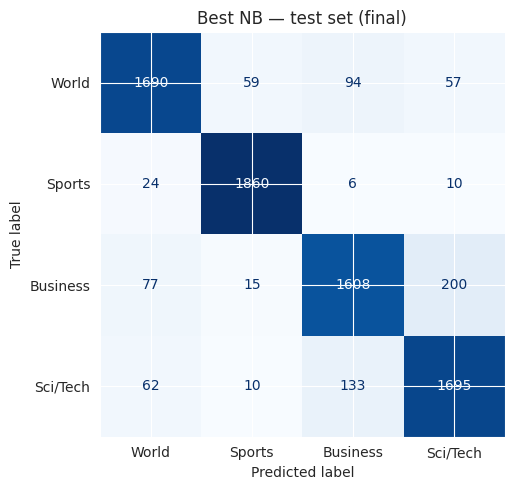


Test accuracy:  0.9017
Test macro F1:  0.9015


In [12]:
# ── Select your best pipeline configuration here ──────────────────────────────
# YOUR CODE HERE — train the best config, predict on test_texts
# test_pred = ...

pipe_final = build_nb_pipeline(alpha=0.01, vectorizer="tfidf")
pipe_final.fit(train_texts, train_labels)
test_pred = pipe_final.predict(test_texts)

results_test = evaluate_classifier(
    test_labels, test_pred, label_names,  # noqa: F821
    title="Best NB — test set (final)",
)
print(f"\nTest accuracy:  {results_test['accuracy']:.4f}")
print(f"Test macro F1:  {results_test['macro_f1']:.4f}")

---

## Part 7 — Error analysis

Understanding where the model fails is as important as the metric.
Sample 10 misclassified examples from the validation set and analyse them.

In [16]:
def sample_errors(
    texts: list[str],
    y_true: list[int],
    y_pred: np.ndarray,
    label_names: list[str],
    n: int = 10,
    seed: int = SEED,
) -> pd.DataFrame:
    """Sample n misclassified documents for qualitative analysis.

    Parameters
    ----------
    texts : list[str]
        Input documents.
    y_true : list[int]
        Ground-truth labels.
    y_pred : np.ndarray
        Predicted labels.
    label_names : list[str]
        Human-readable class names.
    n : int
        Number of errors to sample.
    seed : int
        Random seed.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['text', 'true_label', 'predicted_label'].
    """
    # YOUR CODE HERE
    rng = np.random.default_rng(seed)
    error_idx = np.where(np.array(y_true) != y_pred)[0]

    sampled = rng.choice(error_idx, size=min(n, len(error_idx)), replace=False)

    return pd.DataFrame({
        "text": [texts[i] for i in sampled],
        "true_label": [label_names[y_true[i]] for i in sampled],
        "predicted_label": [label_names[y_pred[i]] for i in sampled],
        })


errors = sample_errors(val_texts, val_labels, val_pred_nb, label_names)
pd.set_option("display.max_colwidth", 120)
print(errors.to_string(index=False))

                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text true_label predicted_label
                                                                                                                                                                                                                                                                 intel clouded by back to school fears intel corp 39 s intc o quote profile research upcoming mid quarter report will be closely watched for signs of weak back to school computer sales though recent   Sci/Tech        Business
                                    

📝 **Your analysis (7)**

1. What are the most common error patterns? (e.g. Business ↔ Sci/Tech confusion)

Looking at the 10 errors, two confusion patterns dominate:
- Business ↔ Sci/Tech (4 cases): Intel, Microsoft/Halo, gym gear, Google IPO. Tech companies and their financial results sit at the boundary of both classes.
- World ↔ Business (3 cases): flu vaccine/Chiron Corp, stocks/employment report, depression drugs. Articles mentioning corporations or financial data in a broader news context get pulled toward Business.

Sports is generally reliable but fails when articles mix domains (Ali in Congress → World, NFL with HTML artifacts → Sci/Tech).

2. Pick two specific misclassified examples and explain why the model got them wrong from a BoW perspective.

Intel (Sci/Tech → Business): The article discusses Intel's upcoming earnings report and "back to school computer sales". A BoW model sees tokens like "quote", "profile", "report", "sales", "mid quarter", all strongly associated
with Business in training. The tech context ("intel", "computer") is not enough to override the financial vocabulary.

NFL article (Sports → Sci/Tech): The original article contained <em> HTML tags which after preprocessing become the
tokens "lt", "em", "gt". These web artifact tokens are strongly associated with Sci/Tech articles in the training corpus (tech news websites use more HTML). A single preprocessing failure is enough to misclassify the whole document.

3. What feature engineering change could fix one of these errors?

For the HTML artifact issue (Sports → Sci/Tech): add "lt", "gt", "em", "amp" to the stop_words list in CountVectorizer, or use min_df=5 to filter tokens that appear in fewer than 5 documents, these artifacts are rare enough that they would be removed. For the Business/Sci/Tech confusion: adding bigrams with a higher max_features (e.g. 200,000) would help capture phrases like "earnings report" vs "product release" that disambiguate the two classes.

---

## Summary — Results table

Fill in after completing all parts. This table feeds into the running course comparison.

In [18]:
results_table = pd.DataFrame([
      {
          "model":        "Majority baseline",
          "features":     "none",
          "val_macro_f1": 0.25,
          "test_macro_f1": 0.25,
      },
      {
          "model":        "Scratch NB",
          "features":     "BoW count (α=1.0)",
          "val_macro_f1": results_scratch["macro_f1"],
          "test_macro_f1": "—",
      },
      {
          "model":        "sklearn NB",
          "features":     "BoW count (α=1.0)",
          "val_macro_f1": results_nb["macro_f1"],
          "test_macro_f1": "—",
      },
      {
          "model":        "sklearn NB (best α=0.01)",
          "features":     "BoW count",
          "val_macro_f1": round(sweep_df.loc[sweep_df["val_macro_f1"].idxmax(), "val_macro_f1"], 4),
          "test_macro_f1": "—",
      },
      {
          "model":        "sklearn NB (best α=0.01)",
          "features":     "TF-IDF unigrams",
          "val_macro_f1": round(comparison_df.loc[comparison_df["vectorizer"]=="tfidf", "val_macro_f1"].values[0], 4),
          "test_macro_f1": results_test["macro_f1"],
      },
      {
          "model":        "sklearn NB (best α=0.01)",
          "features":     "BoW unigrams+bigrams",
          "val_macro_f1": round(ngram_df.loc[ngram_df["features"]=="unigrams+bigrams", "val_macro_f1"].values[0], 4),
          "test_macro_f1": "—",
      },
  ])
print(results_table.to_string(index=False))

                   model             features  val_macro_f1 test_macro_f1
       Majority baseline                 none      0.250000          0.25
              Scratch NB    BoW count (α=1.0)      0.903331             —
              sklearn NB    BoW count (α=1.0)      0.903421             —
sklearn NB (best α=0.01)            BoW count      0.906400             —
sklearn NB (best α=0.01)      TF-IDF unigrams      0.907100       0.90145
sklearn NB (best α=0.01) BoW unigrams+bigrams      0.903100             —
